# Analyse des données League of Legends

**Problématique** : Analyser et trouver quel est le meilleur champion et quels sont les rôles et les positions les plus représentés

#### Initialisation des librairies

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

path = "data/"

#### Initialisation des Datasets

##### Champion Dataset

In [ ]:
champs = pd.read_csv(path + "champs.csv")

##### Participants Dataset

In [ ]:
participants = pd.read_csv(path + "participants.csv")

##### Matches Dataset

In [ ]:
matches = pd.read_csv(path + "matches.csv")

##### Stat1 Dataset

In [ ]:
stats1 = pd.read_csv(path + "stats1.csv")

##### Stat2 Dataset

In [ ]:
stats2 = pd.read_csv(path + "stats2.csv", na_values=[r"\N"], dtype={"wardsbought": "Int64"})

##### Team Bans Dataframe

In [ ]:
teambans = pd.read_csv(path + "teambans.csv")

##### Team Stats Dataframe

In [ ]:
teamstats = pd.read_csv(path + "teamstats.csv")

#### Tests et analyse

In [ ]:
# python
# quick diagnostics
print(participants.shape)
print(participants.columns.tolist())
print(participants['position'].dtype, participants['role'].dtype)
print(participants['position'].isna().sum(), participants['role'].isna().sum())
print(participants[['position', 'role']].head())

# vectorized fix (fast)
mask_bot = participants['position'] == "BOT"
participants.loc[mask_bot & (participants['role'] == 'DUO_SUPPORT'), 'position'] = "SUPP"
participants.loc[mask_bot & (participants['role'] != 'DUO_SUPPORT'), 'position'] = "ADC"

# verify
participants.loc[:, ["position", "role"]].head()

print(participants['championid'].dtype, champs['id'].dtype)


In [ ]:
participants["teamid"] = participants.player.apply(lambda x: 100 if x <= 5 else 200)

keep_cols_stats = ["id", "win", "kills"]
keep_cols_participants = ['id', 'champion_name', 'player', 'win', 'kills', 'deaths', 'assists','ss1', 'ss2', 'position']

stats = pd.concat([stats1, stats2])

train_data = pd.merge(participants, teamstats.drop(["firstblood"], axis=1), on=["matchid", "teamid"])
train_data = pd.merge(participants, stats, how='left', on=['id'], suffixes=('', '_y'))

champs_info = champs[['id', 'name']].rename(columns={'name': 'champion_name'})

train_data = pd.merge(train_data, champs_info, left_on='championid', right_on='id', how='left', suffixes=('', '_champ'))

train_data = train_data[keep_cols_participants]
only_winners = train_data[train_data["win"] == 1]

only_winners

Text(0, 0.5, 'Nombre de kills')

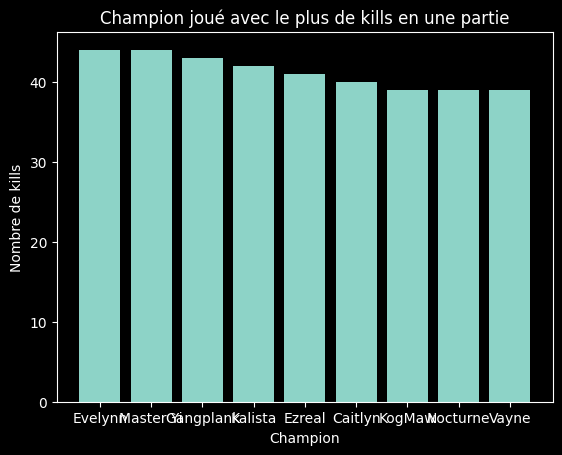

In [27]:
plt.figure()

selected = only_winners.sort_values(by="kills", ascending=False).head(10)

plt.bar(selected["champion_name"], selected["kills"])

plt.title("Champion joué avec le plus de kills en une partie")
plt.xlabel("Champion")
plt.ylabel("Nombre de kills")